# Image Processing Notebook: Plot the H Cross-Section (from Transmission)


This notebook takes the processed transmission imagesand plot the H Cross-sections from specific ROIs

## Initial Settings

### Import Libraries

In [1]:
import sys
sys.path.append(r'..\01_Functions')
from step_functions import *
from dict_functions import *
from proc_functions import *
from img_functions import *
from plotting_cs import *
from cross_sections import *
import seaborn as sns
%matplotlib inline
pd.set_option('display.max_rows', 20)

### Provide the Spectra.txt file from any of the experiments. 
These are the neutron arrival times the MCP detected

In [2]:
# %load select_file('spectra_file')
spectra_file = r"J:\700 Campaigns - internal\2022\PSI22_04NI\Raw_images\exp2000\exp2200_LP40_deg\02_pos00\IMAT00018918_02_pos00_001_Spectra.txt"

### Provide the directory for saving results

In [3]:
# %load select_directory('dst_dir')
dst_dir = r"J:\700 Campaigns - internal\2022\PSI22_04NI\00_Processed\02_Cross_sections_results\01_operando"

### Provide the directory freference measurements (this is a special case)

In [4]:
# %load select_directory('ref_dir')
ref_dir = r"J:\700 Campaigns - internal\2022\PSI22_04NI\00_Processed\01_Transmission_results\000_exp2000\00_empty_ref02"

### Set the ROIs to analyze

In [5]:
ref_dict = read_saved_dict (ref_dir, proc_folder = [])

Reading Images: 100%|████████████████████████████| 5/5 [00:00<00:00,  7.90it/s]


#### Extract an averaged image for each key
For each `proc_folder` (acquisition), an averaged image will be extracted

In [6]:
avg_imgs = []
for key, value in ref_dict.items():
    img =  avg_frames_dict (value, output_type = 'img', start_img = 15, end_slice = 20)
    avg_imgs.append(img[0])

#### Select the ROIs
For simplicity handling the names, `ROIs_` before the name of the `proc_folder` is required

In [7]:
# %load select_multiple_rois(proc_folder[0], avg_images[0], cmap = 'flag')

# from each chip region LP30 degraded
ROIs_02_pos00 = [[146, 35, 78, 69], [33, 35, 78, 69], [32, 154, 78, 69], [145, 152, 78, 69]]
ROIs_04_pos01 = [[146, 35, 78, 69], [33, 35, 78, 69], [32, 154, 78, 38], [145, 152, 78, 40]] #
ROIs_06_pos02 = [[146, 35, 78, 69], [33, 35, 78, 69], [32, 154, 78, 69], [145, 152, 78, 69]]
ROIs_08_pos03 = [[146, 35, 78, 69], [33, 35, 78, 69], [33, 154, 78, 69], [145, 152, 78, 69]]
ROIs_10_pos04 = [[146, 35, 78, 69], [33, 35, 78, 69], [32, 154, 78, 69], [145, 152, 78, 69]]

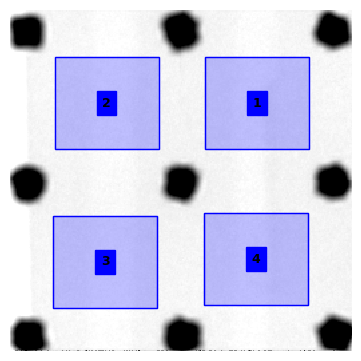

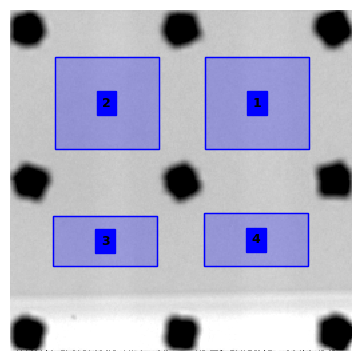

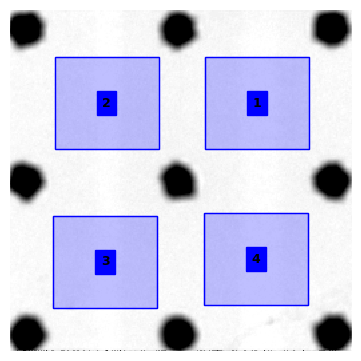

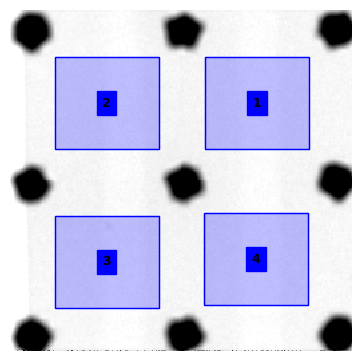

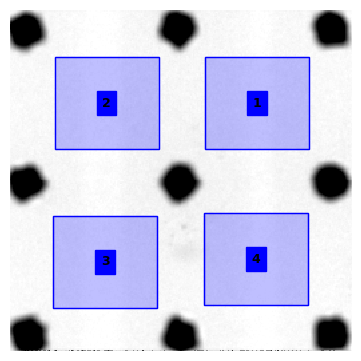

In [8]:
show_img(avg_imgs[0], dr = [(ROIs_02_pos00, 'blue')], cmap='gray', nrows=3, ncols=2, index=1)
show_img(avg_imgs[1], dr = [(ROIs_04_pos01, 'blue')], cmap='gray', nrows=3, ncols=2, index=2)
show_img(avg_imgs[2], dr = [(ROIs_06_pos02, 'blue')], cmap='gray', nrows=3, ncols=2, index=3)
show_img(avg_imgs[3], dr = [(ROIs_08_pos03, 'blue')], cmap='gray', nrows=3, ncols=2, index=4)
show_img(avg_imgs[4], dr = [(ROIs_10_pos04, 'blue')], cmap='gray', nrows=3, ncols=2, index=5)

#### Create a dictionary of the ROIs

In [9]:
rois_dict = {}
for name in ref_dict.keys():
    rois_name = 'ROIs_'+ name
    for rois in [rois_name]:
        rois_dict[rois] = eval(rois)

## Pre-operation 20C

### To transmission images

In [10]:
src_dir = r"J:\700 Campaigns - internal\2022\PSI22_04NI\00_Processed\01_Transmission_results\000_exp3000\00_LP30_pre_oper_20C"

### Read the directory and setup the ROIs
You can specify a single folder but if you want all the folders in the `src_dir`, leave `proc_folder=[]`.

In [11]:
src_dict = read_saved_dict (src_dir, proc_folder = [])
ref_dict = read_saved_dict (ref_dir, proc_folder = [])

Reading Images: 100%|████████████████████████████| 5/5 [00:00<00:00,  8.54it/s]


### Extract the values

In [12]:
img_vals = get_roi_values (src_dict, rois_dict, spectra_file, save_path = dst_dir, binning = 20, 
                                 flight_path = 56, start_slice = 0, name_xlsx = 'Roi_values_auto.xlsx', 
                                 save_results = False)

ref_vals = get_roi_values (ref_dict, rois_dict, spectra_file, save_path = dst_dir, binning = 20, 
                                 flight_path = 56, start_slice = 0, name_xlsx = 'Roi_values_auto.xlsx', 
                                 save_results = False)

In [13]:
data_wvl = img_vals['Wavelength [Å]']

ref_vals = ref_vals.loc[2:36]
ref_vals = ref_vals.reset_index(drop=True)

img_vals = img_vals.loc[2:36]
img_vals = img_vals.reset_index(drop=True)

In [14]:
trans_rois = prepare_trans_data(img_vals, data_ref = ref_vals, data_output = 'transmission')

In [15]:
trans_rois

,Wavelength [Å],Transmission_02_pos00_roi_1,Transmission_02_pos00_roi_2,Transmission_02_pos00_roi_3,Transmission_02_pos00_roi_4,Transmission_04_pos01_roi_1,Transmission_04_pos01_roi_2,Transmission_04_pos01_roi_3,Transmission_04_pos01_roi_4,Transmission_06_pos02_roi_1,...,Transmission_06_pos02_roi_3,Transmission_06_pos02_roi_4,Transmission_08_pos03_roi_1,Transmission_08_pos03_roi_2,Transmission_08_pos03_roi_3,Transmission_08_pos03_roi_4,Transmission_10_pos04_roi_1,Transmission_10_pos04_roi_2,Transmission_10_pos04_roi_3,Transmission_10_pos04_roi_4
0,1.279359,0.882037,0.884222,0.885934,0.880615,0.876557,0.876480,0.883761,0.876265,0.880069,...,0.887108,0.883530,0.886484,0.882980,0.885199,0.892490,0.887326,0.887120,0.889080,0.886292
1,1.531952,0.871501,0.872530,0.876887,0.870567,0.874158,0.874179,0.876094,0.872207,0.872978,...,0.877172,0.877637,0.875364,0.874496,0.879036,0.876071,0.871314,0.872886,0.877202,0.871850
2,1.776463,0.859802,0.861646,0.863980,0.858267,0.864232,0.861020,0.865333,0.863073,0.864822,...,0.867074,0.868014,0.865527,0.864117,0.869462,0.868365,0.863788,0.863071,0.865621,0.865323
3,2.032233,0.850217,0.852764,0.854138,0.848979,0.858072,0.857032,0.858433,0.853748,0.857395,...,0.860735,0.861471,0.858810,0.857853,0.861873,0.862238,0.859271,0.858528,0.861588,0.860427
4,2.304880,0.845480,0.848281,0.850727,0.843699,0.852734,0.852063,0.853130,0.848239,0.852533,...,0.854213,0.856213,0.853387,0.852501,0.855844,0.855431,0.851770,0.852804,0.855736,0.853316
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30,8.806118,0.734987,0.729368,0.729698,0.728958,0.746058,0.748867,0.732723,0.727803,0.746130,...,0.742125,0.743063,0.737277,0.722908,0.731351,0.741149,0.725199,0.734529,0.735408,0.729152
31,9.039954,0.736806,0.732595,0.730507,0.731276,0.752983,0.755731,0.739842,0.729820,0.734892,...,0.732088,0.731378,0.723684,0.723476,0.723030,0.728147,0.731825,0.742230,0.743689,0.729196
32,9.271439,0.740201,0.726208,0.735547,0.739169,0.731301,0.725022,0.712850,0.718386,0.731838,...,0.730027,0.736013,0.737481,0.726911,0.722694,0.722974,0.727326,0.732460,0.738305,0.723939
33,9.525303,0.725059,0.719987,0.723399,0.729595,0.731786,0.736024,0.729271,0.718261,0.725147,...,0.725959,0.723944,0.738084,0.732204,0.713626,0.740473,0.719353,0.726913,0.732364,0.723696


### Get the transmission table
If the images given before are transmission, leave empty the data_ref in the `prepare_trans_data` function. 
If not, run the previous line but with the reference images directory.

Depending on the **data_output** chosen ('transmission'. 'optical density', 'total cs', or 'h cs'). if the requested data is `total cs` or `h cs`, a dictionary of compounds is required. This is basically a list of the material expected **in oder** from the ROIs given before.

The  full dictionary of cross-sections is located at the top of the `plotting_cs` function. In the notebook, we are using only those that are required to avoid clogging the information.

#### H cross section parameters

In [16]:
thickness = 0.060

ec = {'abbv': 'EC', 'composition' : {'C':3.0, 'H':4.0, 'O':3.0},'density':1.32, 'thickness': thickness}
dmc = {'abbv': 'DMC','composition' : {'C':3.0, 'H':6.0, 'O':3.0}, 'density':1.07, 'thickness': thickness}
dec = {'abbv': 'DEC','composition' : {'C':5.0, 'H':10.0, 'O':3.0}, 'density':0.975, 'thickness': thickness}
lipf6 = {'abbv': 'LiPF6','composition' : {'LI':1.0, 'P':1.0, 'F':6.0}, 'density':1.5, 'thickness': thickness}
ec_dmc_11v = {'abbv': 'EC_DMC (1:1v)','molecules' : [ec,0.5,dmc,0.5], 'density':1.1955, 'thickness': thickness}
ec_dec_11v = {'abbv': 'EC_DEC (1:1v)','molecules' : [ec,0.5,dec,0.5], 'density':1.148, 'thickness': thickness}
#lp30 = {'abbv': 'LP30','molecules' : [ec, 0.501683056,dmc, 0.406359477, lipf6, 0.091957467], 'density':1.2795, 'thickness': thickness}
#lp40 = {'abbv': 'LP40','molecules' : [ec, 0.447925137,dec, 0.447925137, lipf6, 0.104149725], 'density':1.2635, 'thickness': thickness}

lp30 = {'abbv': 'LP30','molecules' : [ec, 0.446003162,dmc, 0.446003162, lipf6, 0.107993676], 'density':1.2284, 'thickness': thickness}
lp40 = {'abbv': 'LP40','molecules' : [ec, 0.447925137,dec, 0.447925137, lipf6, 0.104149725], 'density':1.1847, 'thickness': thickness}

In [17]:
compounds_dict = [lp30, lp30, lp30, lp30, lp30, lp30, lp30, lp30, lp30, lp30,
                 lp30, lp30, lp30, lp30, lp30, lp30, lp30, lp30, lp30, lp30]

#### Get the cross sections
Function to get the cross sections, the requested_cs is a list of the desired cross-sections options are ['total_cs','h_cs','li_cs']

**it was determined that an interpolation via Savgol of 5,2 does not affect the outcome but improves the data visualization. Therefore, it was kept**

In [18]:
res_data = prepare_trans_data(trans_rois, data_output = 'h cs', compounds_dict = compounds_dict)
res_data = dataframe_to_savgol(res_data, 5, 2)

Data_imgs variable taken as transmission images


In [19]:
save_DF (dst_dir, res_data, df_name = '00_insitu_20C_H_CS.xlsx', sheet_name = 'pre_oper_20C', mode = 'w')

In [20]:
    # position column name extraction
pos00 = [column for column in res_data if 'pos00' in column]
pos01 = [column for column in res_data if 'pos01' in column]
pos02 = [column for column in res_data if 'pos02' in column]
pos03 = [column for column in res_data if 'pos03' in column]
pos04 = [column for column in res_data if 'pos04' in column]
    # recalling the data with the specified columns and the wavelength column up front
cs_pos00_dat = pd.concat([data_wvl, res_data[pos00]], axis = 1)
cs_pos01_dat = pd.concat([data_wvl, res_data[pos01]], axis = 1)
cs_pos02_dat = pd.concat([data_wvl, res_data[pos02]], axis = 1)
cs_pos03_dat = pd.concat([data_wvl, res_data[pos03]], axis = 1)
cs_pos04_dat = pd.concat([data_wvl, res_data[pos04]], axis = 1)

avg_vals_dat = pd.DataFrame(data_wvl)
avg_vals_dat ['pos00'] = cs_pos00_dat.iloc[:,1:].mean(axis=1)
avg_vals_dat ['pos01'] = cs_pos01_dat.iloc[:,1:].mean(axis=1)
avg_vals_dat ['pos02'] = cs_pos02_dat.iloc[:,1:].mean(axis=1)
avg_vals_dat ['pos03'] = cs_pos03_dat.iloc[:,1:].mean(axis=1)
avg_vals_dat ['pos04'] = cs_pos04_dat.iloc[:,1:].mean(axis=1)

In [21]:
cs_pos00_dat=cs_pos00_dat.melt('Wavelength [Å]', var_name='val', value_name='cross-section [barns]')
cs_pos01_dat=cs_pos01_dat.melt('Wavelength [Å]', var_name='val', value_name='cross-section [barns]')
cs_pos02_dat=cs_pos02_dat.melt('Wavelength [Å]', var_name='val', value_name='cross-section [barns]')
cs_pos03_dat=cs_pos03_dat.melt('Wavelength [Å]', var_name='val', value_name='cross-section [barns]')
cs_pos04_dat=cs_pos04_dat.melt('Wavelength [Å]', var_name='val', value_name='cross-section [barns]')
avg_vals_dat=avg_vals_dat.melt('Wavelength [Å]', var_name='val', value_name='cross-section [barns]')

In [22]:
#sns.relplot(data = cs_pos01_dat, x = 'Wavelength [Å]', y = 'cross-section [barns]', hue = 'val', 
#            kind = 'line', legend = 'brief', height=6, aspect=1.2)

<AxesSubplot:xlabel='Wavelength [Å]', ylabel='cross-section [barns]'>

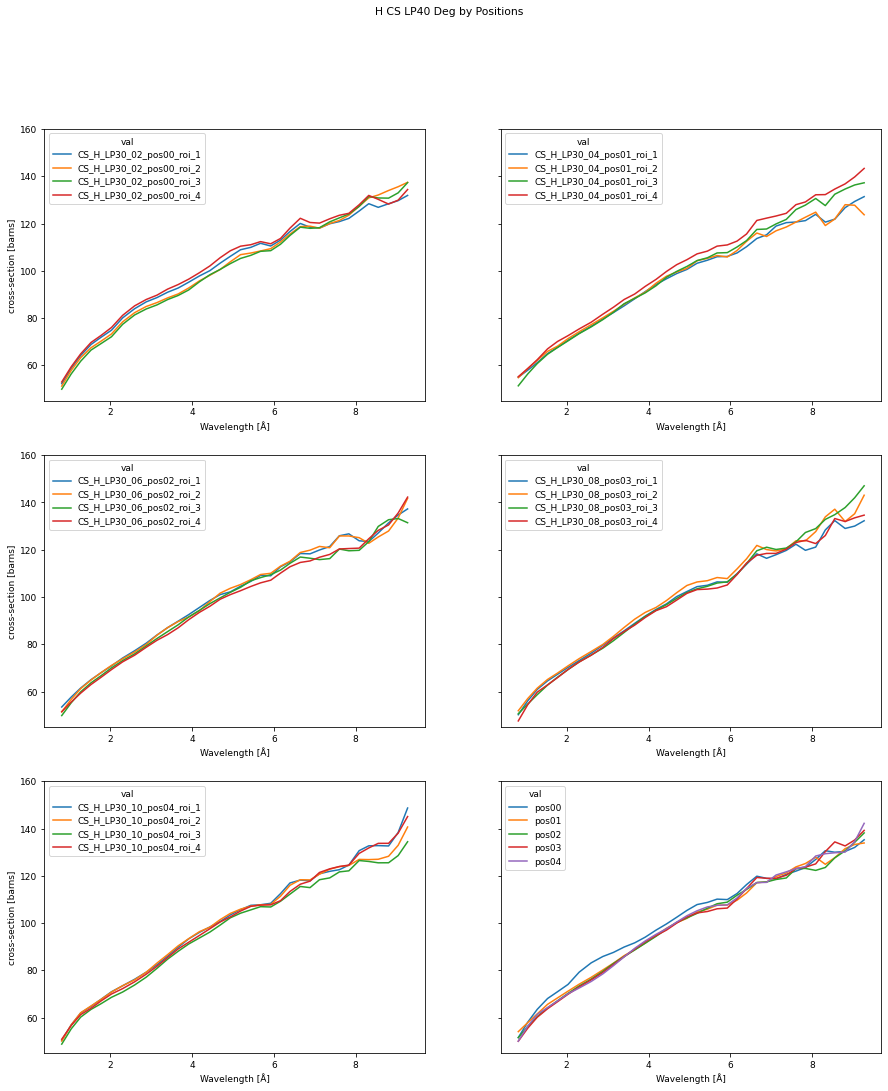

In [23]:
fig0, ax = plt.subplots(3,2, figsize = (15,17), sharey = True)
fig0.suptitle('H CS LP40 Deg by Positions')
plt.ylim([45,160])
sns.lineplot(ax = ax[0,0], data = cs_pos00_dat, x = 'Wavelength [Å]', y = 'cross-section [barns]', hue = 'val')
sns.lineplot(ax = ax[0,1], data = cs_pos01_dat, x = 'Wavelength [Å]', y = 'cross-section [barns]', hue = 'val')
sns.lineplot(ax = ax[1,0], data = cs_pos02_dat, x = 'Wavelength [Å]', y = 'cross-section [barns]', hue = 'val')
sns.lineplot(ax = ax[1,1], data = cs_pos03_dat, x = 'Wavelength [Å]', y = 'cross-section [barns]', hue = 'val')
sns.lineplot(ax = ax[2,0], data = cs_pos04_dat, x = 'Wavelength [Å]', y = 'cross-section [barns]', hue = 'val')
sns.lineplot(ax = ax[2,1], data = avg_vals_dat, x = 'Wavelength [Å]', y = 'cross-section [barns]', hue = 'val')

## After-operation 20C

### To transmission images

In [24]:
src_dir = r"J:\700 Campaigns - internal\2022\PSI22_04NI\00_Processed\01_Transmission_results\000_exp3000\02_LP30_after_oper_20C"

### Read the directory and setup the ROIs
You can specify a single folder but if you want all the folders in the `src_dir`, leave `proc_folder=[]`.

In [25]:
src_dict = read_saved_dict (src_dir, proc_folder = [])
ref_dict = read_saved_dict (ref_dir, proc_folder = [])

Reading Images: 100%|████████████████████████████| 5/5 [00:00<00:00,  7.27it/s]


### Extract the values

In [26]:
img_vals = get_roi_values (src_dict, rois_dict, spectra_file, save_path = dst_dir, binning = 20, 
                                 flight_path = 56, start_slice = 0, name_xlsx = 'Roi_values_auto.xlsx', 
                                 save_results = False)

ref_vals = get_roi_values (ref_dict, rois_dict, spectra_file, save_path = dst_dir, binning = 20, 
                                 flight_path = 56, start_slice = 0, name_xlsx = 'Roi_values_auto.xlsx', 
                                 save_results = False)

In [27]:
data_wvl = img_vals['Wavelength [Å]']

ref_vals = ref_vals.loc[2:36]
ref_vals = ref_vals.reset_index(drop=True)

img_vals = img_vals.loc[2:36]
img_vals = img_vals.reset_index(drop=True)

In [28]:
trans_rois = prepare_trans_data(img_vals, data_ref = ref_vals, data_output = 'transmission')

In [29]:
trans_rois

,Wavelength [Å],Transmission_02_pos00_roi_1,Transmission_02_pos00_roi_2,Transmission_02_pos00_roi_3,Transmission_02_pos00_roi_4,Transmission_04_pos01_roi_1,Transmission_04_pos01_roi_2,Transmission_04_pos01_roi_3,Transmission_04_pos01_roi_4,Transmission_06_pos02_roi_1,...,Transmission_06_pos02_roi_3,Transmission_06_pos02_roi_4,Transmission_08_pos03_roi_1,Transmission_08_pos03_roi_2,Transmission_08_pos03_roi_3,Transmission_08_pos03_roi_4,Transmission_10_pos04_roi_1,Transmission_10_pos04_roi_2,Transmission_10_pos04_roi_3,Transmission_10_pos04_roi_4
0,1.279359,0.881226,0.878616,0.883791,0.877185,0.881732,0.882023,0.885755,0.880370,0.873884,...,0.880848,0.878336,0.884521,0.883158,0.884992,0.890240,0.876984,0.878185,0.885953,0.887707
1,1.531952,0.870360,0.871474,0.874139,0.868704,0.870413,0.872137,0.872449,0.868728,0.868727,...,0.872051,0.875560,0.876672,0.870787,0.874741,0.872025,0.872203,0.870723,0.875751,0.873278
2,1.776463,0.859738,0.859855,0.863205,0.858995,0.861998,0.860102,0.860630,0.860775,0.858127,...,0.864773,0.865507,0.864403,0.861472,0.866469,0.863950,0.866150,0.864193,0.867242,0.867016
3,2.032233,0.854241,0.854747,0.856147,0.853211,0.855035,0.856603,0.857509,0.854860,0.851588,...,0.856584,0.858986,0.859646,0.856651,0.861244,0.860055,0.859498,0.858669,0.863341,0.861737
4,2.304880,0.849265,0.849381,0.852957,0.848155,0.850928,0.850355,0.852526,0.849254,0.847262,...,0.852874,0.855181,0.852681,0.849585,0.854255,0.852694,0.853161,0.852115,0.855535,0.854406
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30,8.806118,0.729235,0.726857,0.725222,0.723732,0.745906,0.745078,0.728432,0.731308,0.736396,...,0.738562,0.736957,0.740587,0.727258,0.741140,0.742179,0.730300,0.733071,0.731765,0.734491
31,9.039954,0.740124,0.733147,0.729239,0.733530,0.732338,0.736243,0.731010,0.726881,0.726559,...,0.741920,0.735578,0.740045,0.723729,0.728458,0.732690,0.734237,0.740582,0.741140,0.733666
32,9.271439,0.734890,0.724592,0.731829,0.736610,0.733150,0.740080,0.724759,0.714466,0.733641,...,0.739956,0.736351,0.728603,0.730297,0.713327,0.726946,0.738267,0.733301,0.736381,0.736659
33,9.525303,0.723095,0.722704,0.726737,0.739682,0.730178,0.735786,0.725445,0.719688,0.720243,...,0.735129,0.727159,0.728166,0.721881,0.712751,0.730774,0.727391,0.735573,0.745923,0.732556


### Get the transmission table
If the images given before are transmission, leave empty the data_ref in the `prepare_trans_data` function. 
If not, run the previous line but with the reference images directory.

Depending on the **data_output** chosen ('transmission'. 'optical density', 'total cs', or 'h cs'). if the requested data is `total cs` or `h cs`, a dictionary of compounds is required. This is basically a list of the material expected **in oder** from the ROIs given before.

The  full dictionary of cross-sections is located at the top of the `plotting_cs` function. In the notebook, we are using only those that are required to avoid clogging the information.

#### H cross section parameters

In [30]:
thickness = 0.060

ec = {'abbv': 'EC', 'composition' : {'C':3.0, 'H':4.0, 'O':3.0},'density':1.32, 'thickness': thickness}
dmc = {'abbv': 'DMC','composition' : {'C':3.0, 'H':6.0, 'O':3.0}, 'density':1.07, 'thickness': thickness}
dec = {'abbv': 'DEC','composition' : {'C':5.0, 'H':10.0, 'O':3.0}, 'density':0.975, 'thickness': thickness}
lipf6 = {'abbv': 'LiPF6','composition' : {'LI':1.0, 'P':1.0, 'F':6.0}, 'density':1.5, 'thickness': thickness}
ec_dmc_11v = {'abbv': 'EC_DMC (1:1v)','molecules' : [ec,0.5,dmc,0.5], 'density':1.1955, 'thickness': thickness}
ec_dec_11v = {'abbv': 'EC_DEC (1:1v)','molecules' : [ec,0.5,dec,0.5], 'density':1.148, 'thickness': thickness}
#lp30 = {'abbv': 'LP30','molecules' : [ec, 0.501683056,dmc, 0.406359477, lipf6, 0.091957467], 'density':1.2795, 'thickness': thickness}
#lp40 = {'abbv': 'LP40','molecules' : [ec, 0.447925137,dec, 0.447925137, lipf6, 0.104149725], 'density':1.2635, 'thickness': thickness}

lp30 = {'abbv': 'LP30','molecules' : [ec, 0.446003162,dmc, 0.446003162, lipf6, 0.107993676], 'density':1.2284, 'thickness': thickness}
lp40 = {'abbv': 'LP40','molecules' : [ec, 0.447925137,dec, 0.447925137, lipf6, 0.104149725], 'density':1.1847, 'thickness': thickness}

In [31]:
compounds_dict = [lp30, lp30, lp30, lp30, lp30, lp30, lp30, lp30, lp30, lp30,
                 lp30, lp30, lp30, lp30, lp30, lp30, lp30, lp30, lp30, lp30]

#### Get the cross sections
Function to get the cross sections, the requested_cs is a list of the desired cross-sections options are ['total_cs','h_cs','li_cs']

**it was determined that an interpolation via Savgol of 5,2 does not affect the outcome but improves the data visualization. Therefore, it was kept**

In [32]:
res_data = prepare_trans_data(trans_rois, data_output = 'h cs', compounds_dict = compounds_dict)
res_data = dataframe_to_savgol(res_data, 5, 2)

Data_imgs variable taken as transmission images


In [33]:
save_DF (dst_dir, res_data, df_name = '00_insitu_20C_H_CS.xlsx', sheet_name = 'after_oper_20C', mode = 'a')

In [34]:
    # position column name extraction
pos00 = [column for column in res_data if 'pos00' in column]
pos01 = [column for column in res_data if 'pos01' in column]
pos02 = [column for column in res_data if 'pos02' in column]
pos03 = [column for column in res_data if 'pos03' in column]
pos04 = [column for column in res_data if 'pos04' in column]
    # recalling the data with the specified columns and the wavelength column up front
cs_pos00_dat = pd.concat([data_wvl, res_data[pos00]], axis = 1)
cs_pos01_dat = pd.concat([data_wvl, res_data[pos01]], axis = 1)
cs_pos02_dat = pd.concat([data_wvl, res_data[pos02]], axis = 1)
cs_pos03_dat = pd.concat([data_wvl, res_data[pos03]], axis = 1)
cs_pos04_dat = pd.concat([data_wvl, res_data[pos04]], axis = 1)

avg_vals_dat = pd.DataFrame(data_wvl)
avg_vals_dat ['pos00'] = cs_pos00_dat.iloc[:,1:].mean(axis=1)
avg_vals_dat ['pos01'] = cs_pos01_dat.iloc[:,1:].mean(axis=1)
avg_vals_dat ['pos02'] = cs_pos02_dat.iloc[:,1:].mean(axis=1)
avg_vals_dat ['pos03'] = cs_pos03_dat.iloc[:,1:].mean(axis=1)
avg_vals_dat ['pos04'] = cs_pos04_dat.iloc[:,1:].mean(axis=1)

In [35]:
cs_pos00_dat=cs_pos00_dat.melt('Wavelength [Å]', var_name='val', value_name='cross-section [barns]')
cs_pos01_dat=cs_pos01_dat.melt('Wavelength [Å]', var_name='val', value_name='cross-section [barns]')
cs_pos02_dat=cs_pos02_dat.melt('Wavelength [Å]', var_name='val', value_name='cross-section [barns]')
cs_pos03_dat=cs_pos03_dat.melt('Wavelength [Å]', var_name='val', value_name='cross-section [barns]')
cs_pos04_dat=cs_pos04_dat.melt('Wavelength [Å]', var_name='val', value_name='cross-section [barns]')
avg_vals_dat=avg_vals_dat.melt('Wavelength [Å]', var_name='val', value_name='cross-section [barns]')

In [36]:
#sns.relplot(data = cs_pos01_dat, x = 'Wavelength [Å]', y = 'cross-section [barns]', hue = 'val', 
#            kind = 'line', legend = 'brief', height=6, aspect=1.2)

<AxesSubplot:xlabel='Wavelength [Å]', ylabel='cross-section [barns]'>

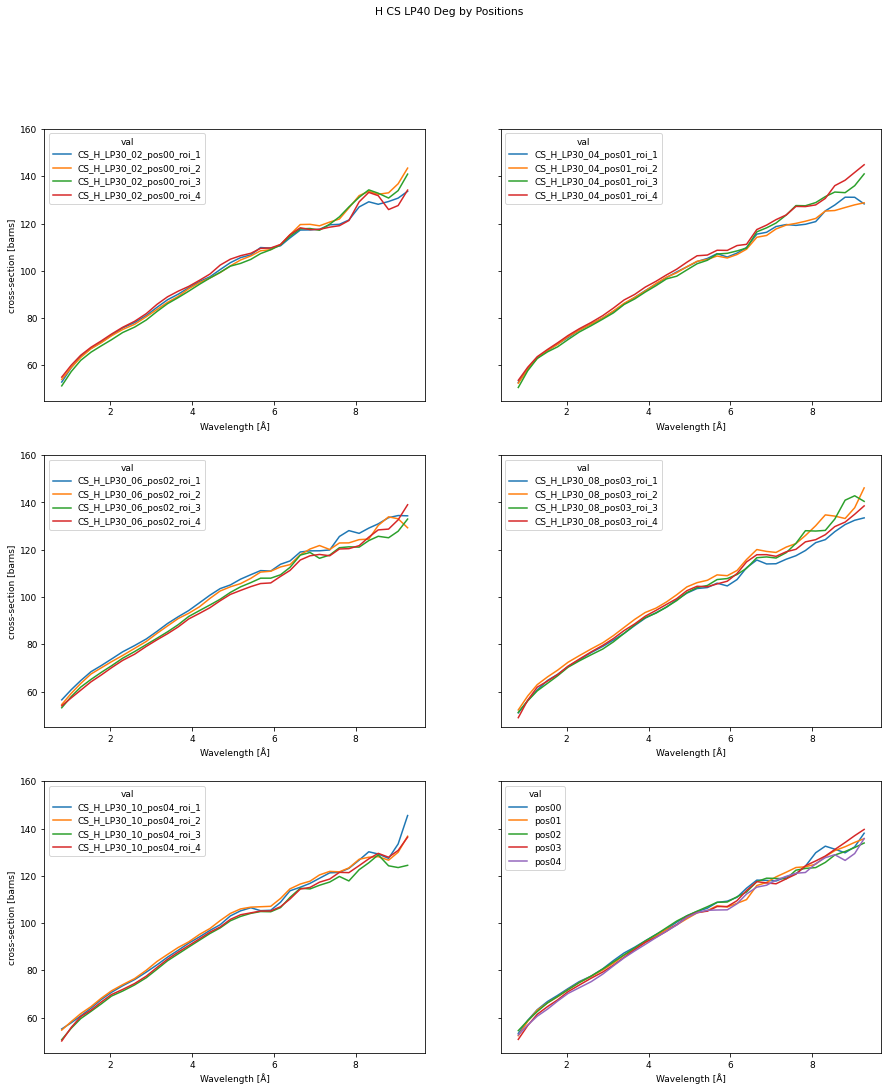

In [37]:
fig0, ax = plt.subplots(3,2, figsize = (15,17), sharey = True)
fig0.suptitle('H CS After operando by Positions')
plt.ylim([45,160])
sns.lineplot(ax = ax[0,0], data = cs_pos00_dat, x = 'Wavelength [Å]', y = 'cross-section [barns]', hue = 'val')
sns.lineplot(ax = ax[0,1], data = cs_pos01_dat, x = 'Wavelength [Å]', y = 'cross-section [barns]', hue = 'val')
sns.lineplot(ax = ax[1,0], data = cs_pos02_dat, x = 'Wavelength [Å]', y = 'cross-section [barns]', hue = 'val')
sns.lineplot(ax = ax[1,1], data = cs_pos03_dat, x = 'Wavelength [Å]', y = 'cross-section [barns]', hue = 'val')
sns.lineplot(ax = ax[2,0], data = cs_pos04_dat, x = 'Wavelength [Å]', y = 'cross-section [barns]', hue = 'val')
sns.lineplot(ax = ax[2,1], data = avg_vals_dat, x = 'Wavelength [Å]', y = 'cross-section [barns]', hue = 'val')

## Operation 20C

### To transmission images

In [38]:
src_dir = r"J:\700 Campaigns - internal\2022\PSI22_04NI\00_Processed\01_Transmission_results\000_exp3000\01_LP30_oper_20C"
ref_dir = r"J:\700 Campaigns - internal\2022\PSI22_04NI\00_Processed\01_Transmission_results\000_exp2000\00_empty_ref02"

### Set the ROIs to analyze

In [39]:
src_dict = read_saved_dict (src_dir, proc_folder = [])
ref_dict = read_saved_dict (ref_dir, proc_folder = ['10_pos04'])

Reading Images: 100%|████████████████████████████| 1/1 [00:00<00:00,  8.17it/s]


#### Extract an averaged image for each key
For each `proc_folder` (acquisition), an averaged image will be extracted

In [40]:
avg_imgs = []
for key, value in src_dict.items():
    img =  avg_frames_dict (value, output_type = 'img', start_img = 15, end_slice = 20)
    avg_imgs.append(img[0])

#### Select the ROIs
For simplicity handling the names, `ROIs_` before the name of the `proc_folder` is required

In [41]:
# %load select_multiple_rois(proc_folder[0], avg_images[0], cmap = 'flag')

# from each chip region LP30 degraded
ROIs_02_pos00 = [[146, 35, 78, 69], [33, 35, 78, 69], [32, 154, 78, 69], [145, 152, 78, 69]]
ROIs_04_pos01 = [[146, 35, 78, 69], [33, 35, 78, 69], [32, 154, 78, 69], [145, 152, 78, 69]]
ROIs_06_pos02 = [[146, 35, 78, 69], [33, 35, 78, 69], [32, 154, 78, 69], [145, 152, 78, 69]]
ROIs_08_pos03 = [[146, 35, 78, 69], [33, 35, 78, 69], [32, 154, 78, 69], [145, 152, 78, 69]]
ROIs_10_pos04 = [[146, 35, 78, 69], [33, 35, 78, 69], [32, 154, 78, 69], [145, 152, 78, 69]]
ROIs_12_pos05 = [[146, 35, 78, 69], [33, 35, 78, 69], [32, 154, 78, 69], [145, 152, 78, 69]]
ROIs_14_pos06 = [[146, 35, 78, 69], [33, 35, 78, 69], [32, 154, 78, 69], [145, 152, 78, 69]]
ROIs_16_pos07 = [[146, 35, 78, 69], [33, 35, 78, 69], [32, 154, 78, 69], [145, 152, 78, 69]]
ROIs_18_pos08 = [[146, 35, 78, 69], [33, 35, 78, 69], [32, 154, 78, 69], [145, 152, 78, 69]]
ROIs_20_pos09 = [[146, 35, 78, 69], [33, 35, 78, 69], [32, 154, 78, 69], [145, 152, 78, 69]]

ROIs_02_pos00


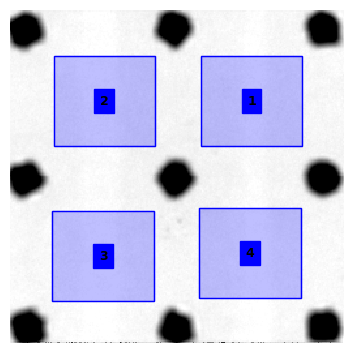

ROIs_04_pos01


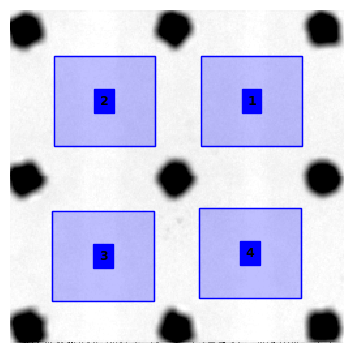

ROIs_06_pos02


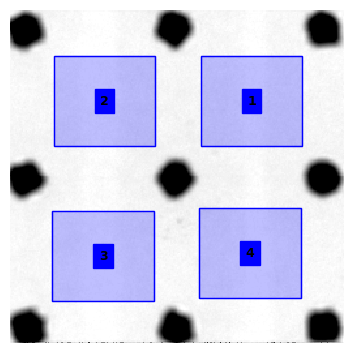

ROIs_08_pos03


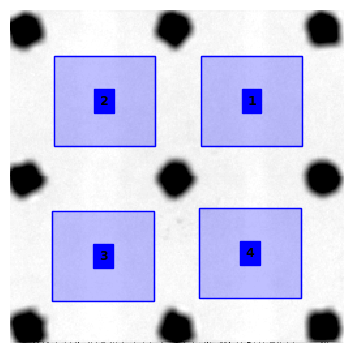

ROIs_10_pos04


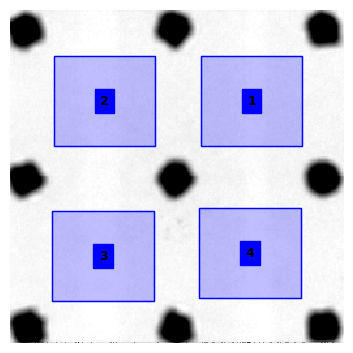

ROIs_12_pos05


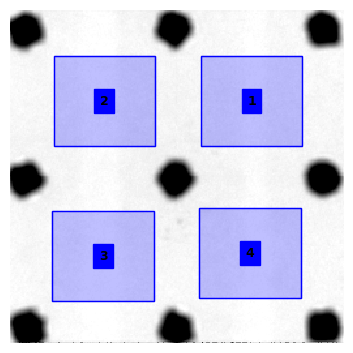

ROIs_14_pos06


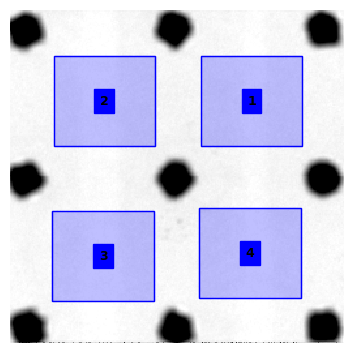

ROIs_16_pos07


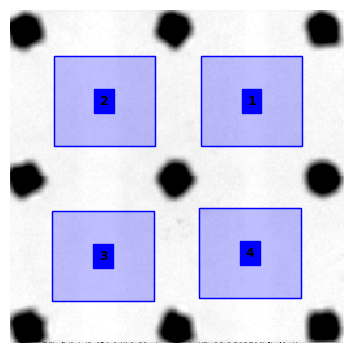

ROIs_18_pos08


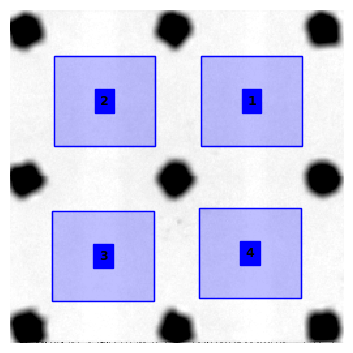

ROIs_20_pos09


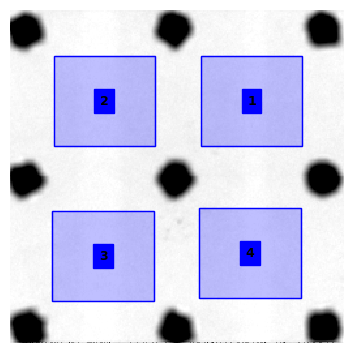

In [42]:
idx = 1
for name in src_dict.keys():
    rois_name = 'ROIs_'+ name
    print(rois_name)
    show_img(avg_imgs[idx-1], dr = [(eval(rois_name), 'blue')], cmap='gray', nrows=5, ncols=2, index=idx)
    idx+=1

#### Create a dictionary of the ROIs

In [43]:
rois_dict = {}
for name in src_dict.keys():
    rois_name = 'ROIs_'+ name
    for rois in [rois_name]:
        rois_dict[rois] = eval(rois)

In [44]:
ref_rois_dict = {}
rois_name = 'ROIs_10_pos04'
for n in range(10):
    ref_rois_dict[rois_name] = eval(rois_name)

### Extract the values

In [45]:
img_vals = get_roi_values (src_dict, rois_dict, spectra_file, save_path = dst_dir, binning = 20, 
                                 flight_path = 56, start_slice = 0, name_xlsx = 'Roi_values_auto.xlsx', 
                                 save_results = False)

ref_vals = get_roi_values (ref_dict, ref_rois_dict, spectra_file, save_path = dst_dir, binning = 20, 
                                 flight_path = 56, start_slice = 0, name_xlsx = 'Roi_values_auto.xlsx', 
                                 save_results = False)

In [47]:
data_wvl = img_vals['Wavelength [Å]']

new_ref_vals = pd.DataFrame()

for name in src_dict.keys():
    for idx in range(1,5,1):
        col_name = 'Values_'+ name + '_roi_' + str(idx)
        new_ref_vals [col_name] = ref_vals ['Values_10_pos04_roi_' + str(idx)]
        
new_ref_vals = pd.concat([data_wvl,new_ref_vals], axis = 1)

In [48]:
data_wvl = img_vals['Wavelength [Å]']

new_ref_vals = new_ref_vals.loc[2:36]
new_ref_vals = new_ref_vals.reset_index(drop=True)

img_vals = img_vals.loc[2:36]
img_vals = img_vals.reset_index(drop=True)

In [49]:
trans_rois = prepare_trans_data(img_vals, data_ref = new_ref_vals, data_output = 'transmission')

### Get the transmission table
If the images given before are transmission, leave empty the data_ref in the `prepare_trans_data` function. 
If not, run the previous line but with the reference images directory.

Depending on the **data_output** chosen ('transmission'. 'optical density', 'total cs', or 'h cs'). if the requested data is `total cs` or `h cs`, a dictionary of compounds is required. This is basically a list of the material expected **in oder** from the ROIs given before.

The  full dictionary of cross-sections is located at the top of the `plotting_cs` function. In the notebook, we are using only those that are required to avoid clogging the information.

#### H cross section parameters

In [51]:
thickness = 0.060

ec = {'abbv': 'EC', 'composition' : {'C':3.0, 'H':4.0, 'O':3.0},'density':1.32, 'thickness': thickness}
dmc = {'abbv': 'DMC','composition' : {'C':3.0, 'H':6.0, 'O':3.0}, 'density':1.07, 'thickness': thickness}
dec = {'abbv': 'DEC','composition' : {'C':5.0, 'H':10.0, 'O':3.0}, 'density':0.975, 'thickness': thickness}
lipf6 = {'abbv': 'LiPF6','composition' : {'LI':1.0, 'P':1.0, 'F':6.0}, 'density':1.5, 'thickness': thickness}
ec_dmc_11v = {'abbv': 'EC_DMC (1:1v)','molecules' : [ec,0.5,dmc,0.5], 'density':1.1955, 'thickness': thickness}
ec_dec_11v = {'abbv': 'EC_DEC (1:1v)','molecules' : [ec,0.5,dec,0.5], 'density':1.148, 'thickness': thickness}
#lp30 = {'abbv': 'LP30','molecules' : [ec, 0.501683056,dmc, 0.406359477, lipf6, 0.091957467], 'density':1.2795, 'thickness': thickness}
#lp40 = {'abbv': 'LP40','molecules' : [ec, 0.447925137,dec, 0.447925137, lipf6, 0.104149725], 'density':1.2635, 'thickness': thickness}

lp30 = {'abbv': 'LP30','molecules' : [ec, 0.446003162,dmc, 0.446003162, lipf6, 0.107993676], 'density':1.2284, 'thickness': thickness}
lp40 = {'abbv': 'LP40','molecules' : [ec, 0.447925137,dec, 0.447925137, lipf6, 0.104149725], 'density':1.1847, 'thickness': thickness}

In [52]:
compounds_dict = [lp30, lp30, lp30, lp30, lp30, lp30, lp30, lp30, lp30, lp30,
                 lp30, lp30, lp30, lp30, lp30, lp30, lp30, lp30, lp30, lp30,
                 lp30, lp30, lp30, lp30, lp30, lp30, lp30, lp30, lp30, lp30,
                 lp30, lp30, lp30, lp30, lp30, lp30, lp30, lp30, lp30, lp30]

#### Get the cross sections
Function to get the cross sections, the requested_cs is a list of the desired cross-sections options are ['total_cs','h_cs','li_cs']

**it was determined that an interpolation via Savgol of 5,2 does not affect the outcome but improves the data visualization. Therefore, it was kept**

In [53]:
res_data = prepare_trans_data(trans_rois, data_output = 'h cs', compounds_dict = compounds_dict)
res_data = dataframe_to_savgol(res_data, 5, 2)

Data_imgs variable taken as transmission images


In [54]:
save_DF (dst_dir, res_data, df_name = '00_insitu_20C_H_CS.xlsx', sheet_name = 'oper_20C', mode = 'a')

In [55]:
    # position column name extraction
pos00 = [column for column in res_data if 'pos00' in column]
pos01 = [column for column in res_data if 'pos01' in column]
pos02 = [column for column in res_data if 'pos02' in column]
pos03 = [column for column in res_data if 'pos03' in column]
pos04 = [column for column in res_data if 'pos04' in column]
pos05 = [column for column in res_data if 'pos05' in column]
pos06 = [column for column in res_data if 'pos06' in column]
pos07 = [column for column in res_data if 'pos07' in column]
pos08 = [column for column in res_data if 'pos08' in column]
pos09 = [column for column in res_data if 'pos09' in column]
    # recalling the data with the specified columns and the wavelength column up front
cs_pos00_dat = pd.concat([data_wvl, res_data[pos00]], axis = 1)
cs_pos01_dat = pd.concat([data_wvl, res_data[pos01]], axis = 1)
cs_pos02_dat = pd.concat([data_wvl, res_data[pos02]], axis = 1)
cs_pos03_dat = pd.concat([data_wvl, res_data[pos03]], axis = 1)
cs_pos04_dat = pd.concat([data_wvl, res_data[pos04]], axis = 1)
cs_pos05_dat = pd.concat([data_wvl, res_data[pos05]], axis = 1)
cs_pos06_dat = pd.concat([data_wvl, res_data[pos06]], axis = 1)
cs_pos07_dat = pd.concat([data_wvl, res_data[pos07]], axis = 1)
cs_pos08_dat = pd.concat([data_wvl, res_data[pos08]], axis = 1)
cs_pos09_dat = pd.concat([data_wvl, res_data[pos09]], axis = 1)

avg_vals_dat = pd.DataFrame(data_wvl)
avg_vals_dat ['pos00'] = cs_pos00_dat.iloc[:,1:].mean(axis=1)
avg_vals_dat ['pos01'] = cs_pos01_dat.iloc[:,1:].mean(axis=1)
avg_vals_dat ['pos02'] = cs_pos02_dat.iloc[:,1:].mean(axis=1)
avg_vals_dat ['pos03'] = cs_pos03_dat.iloc[:,1:].mean(axis=1)
avg_vals_dat ['pos04'] = cs_pos04_dat.iloc[:,1:].mean(axis=1)
avg_vals_dat ['pos05'] = cs_pos05_dat.iloc[:,1:].mean(axis=1)
avg_vals_dat ['pos06'] = cs_pos06_dat.iloc[:,1:].mean(axis=1)
avg_vals_dat ['pos07'] = cs_pos07_dat.iloc[:,1:].mean(axis=1)
avg_vals_dat ['pos08'] = cs_pos08_dat.iloc[:,1:].mean(axis=1)
avg_vals_dat ['pos09'] = cs_pos09_dat.iloc[:,1:].mean(axis=1)

In [56]:
cs_pos00_dat=cs_pos00_dat.melt('Wavelength [Å]', var_name='val', value_name='cross-section [barns]')
cs_pos01_dat=cs_pos01_dat.melt('Wavelength [Å]', var_name='val', value_name='cross-section [barns]')
cs_pos02_dat=cs_pos02_dat.melt('Wavelength [Å]', var_name='val', value_name='cross-section [barns]')
cs_pos03_dat=cs_pos03_dat.melt('Wavelength [Å]', var_name='val', value_name='cross-section [barns]')
cs_pos04_dat=cs_pos04_dat.melt('Wavelength [Å]', var_name='val', value_name='cross-section [barns]')
cs_pos05_dat=cs_pos05_dat.melt('Wavelength [Å]', var_name='val', value_name='cross-section [barns]')
cs_pos06_dat=cs_pos06_dat.melt('Wavelength [Å]', var_name='val', value_name='cross-section [barns]')
cs_pos07_dat=cs_pos07_dat.melt('Wavelength [Å]', var_name='val', value_name='cross-section [barns]')
cs_pos08_dat=cs_pos08_dat.melt('Wavelength [Å]', var_name='val', value_name='cross-section [barns]')
cs_pos09_dat=cs_pos09_dat.melt('Wavelength [Å]', var_name='val', value_name='cross-section [barns]')
avg_vals_dat=avg_vals_dat.melt('Wavelength [Å]', var_name='val', value_name='cross-section [barns]')

In [57]:
#sns.relplot(data = cs_pos01_dat, x = 'Wavelength [Å]', y = 'cross-section [barns]', hue = 'val', 
#            kind = 'line', legend = 'brief', height=6, aspect=1.2)

<AxesSubplot:xlabel='Wavelength [Å]', ylabel='cross-section [barns]'>

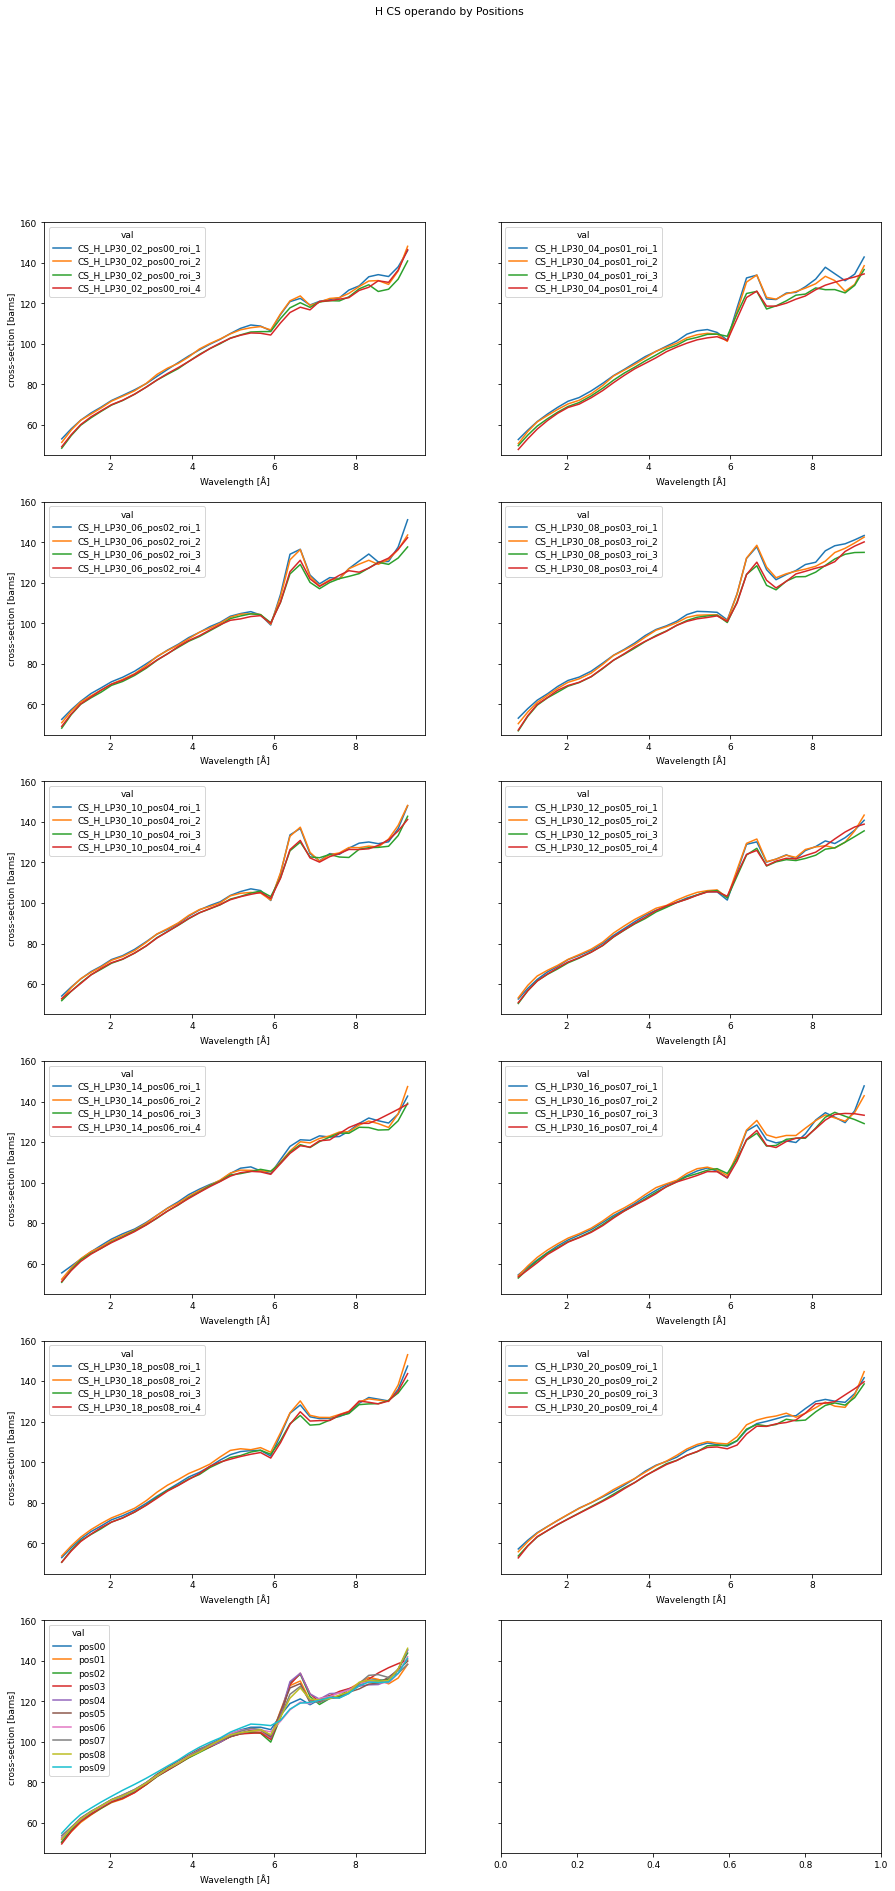

In [58]:
fig0, ax = plt.subplots(6,2, figsize = (15,30), sharey = True)
fig0.suptitle('H CS operando by Positions')
plt.ylim([45,160])
sns.lineplot(ax = ax[0,0], data = cs_pos00_dat, x = 'Wavelength [Å]', y = 'cross-section [barns]', hue = 'val')
sns.lineplot(ax = ax[0,1], data = cs_pos01_dat, x = 'Wavelength [Å]', y = 'cross-section [barns]', hue = 'val')
sns.lineplot(ax = ax[1,0], data = cs_pos02_dat, x = 'Wavelength [Å]', y = 'cross-section [barns]', hue = 'val')
sns.lineplot(ax = ax[1,1], data = cs_pos03_dat, x = 'Wavelength [Å]', y = 'cross-section [barns]', hue = 'val')
sns.lineplot(ax = ax[2,0], data = cs_pos04_dat, x = 'Wavelength [Å]', y = 'cross-section [barns]', hue = 'val')
sns.lineplot(ax = ax[2,1], data = cs_pos05_dat, x = 'Wavelength [Å]', y = 'cross-section [barns]', hue = 'val')
sns.lineplot(ax = ax[3,0], data = cs_pos06_dat, x = 'Wavelength [Å]', y = 'cross-section [barns]', hue = 'val')
sns.lineplot(ax = ax[3,1], data = cs_pos07_dat, x = 'Wavelength [Å]', y = 'cross-section [barns]', hue = 'val')
sns.lineplot(ax = ax[4,0], data = cs_pos08_dat, x = 'Wavelength [Å]', y = 'cross-section [barns]', hue = 'val')
sns.lineplot(ax = ax[4,1], data = cs_pos09_dat, x = 'Wavelength [Å]', y = 'cross-section [barns]', hue = 'val')
sns.lineplot(ax = ax[5,0], data = avg_vals_dat, x = 'Wavelength [Å]', y = 'cross-section [barns]', hue = 'val')